In [14]:
import os
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
from IPython.display import display

from torchvision import transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
N_CLASSES = 8
KERNEL_SIZE = 3
#FLATTENED_IMG_SIZE = IMG_H * IMG_W * IMG_C

model = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=25, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(25),
        nn.ReLU(),        
        nn.MaxPool2d(2, stride = 2),
        nn.Conv2d(in_channels=25, out_channels=50, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(50),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.MaxPool2d(2, stride = 2),
        nn.Conv2d(in_channels=50, out_channels=75, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(75),
        nn.ReLU(),
        nn.MaxPool2d(2, stride = 2),
        nn.Conv2d(in_channels=75, out_channels=75, kernel_size=3, stride=2, padding=1),
        nn.BatchNorm2d(75),
        nn.ReLU(),
        nn.MaxPool2d(2, stride = 2),
        nn.Conv2d(in_channels=75, out_channels=75, kernel_size=3, stride=2, padding=1),
        nn.BatchNorm2d(75),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.MaxPool2d(2, stride = 2),
        nn.Flatten(),
        nn.Linear(1200, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.ReLU(),
        nn.Linear(512, N_CLASSES),
        )

In [7]:
model_path = 'trained_model.pth'
model.load_state_dict(torch.load(model_path, weights_only=True))
model.eval()

Sequential(
  (0): Conv2d(3, 25, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(25, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(25, 50, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.2, inplace=False)
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Conv2d(50, 75, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (10): BatchNorm2d(75, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (11): ReLU()
  (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (13): Conv2d(75, 75, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (14): BatchNorm2d(75, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (15): ReLU()
  (1

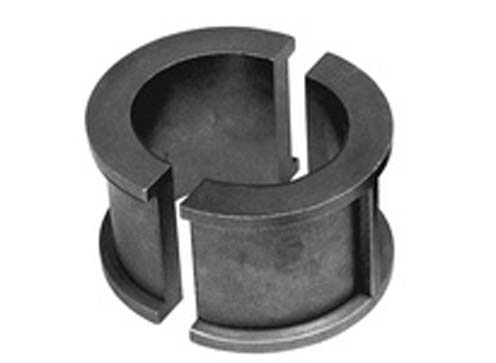

In [41]:
IMG_H = 500
IMG_W = 500
IMG_C = 3

# Transform to resize images
preprocess = transforms.Compose([
    transforms.Resize((IMG_H, IMG_W)),
    transforms.ToTensor(),
])

Excel_path = 'cleaned_product_list.xlsx'

df = pd.read_excel(Excel_path)

img_folder = '/home/hice1/rlopez76/scratch/motion_dataset'
img_name = str(df['PrimaryImageFilename'][3000])

img_name = os.path.join(img_folder, img_name)

img = Image.open(img_name).convert('RGB')

display(img)



In [42]:
img_tensor = preprocess(img).unsqueeze(0)

with torch.no_grad():
    output = model(img_tensor)
    
_, predicted = torch.max(output.data, 1)
print(f"Predicted class index: {predicted.item()}")

Predicted class index: 3
